In [40]:
import random
from typing import List, Dict

import torch
from torch.utils.data import Dataset, DataLoader, Subset

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image
from tqdm.notebook import tqdm

from torchvision.datasets import VOCDetection
from torchvision.transforms import functional as F

from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models import ResNet50_Weights

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cpu


In [42]:
VOC_CLASSES = [
    "__background__",
    "aeroplane",
    "bicycle",
    "bird",
    "boat",
    "bottle",
    "bus",
    "car",
    "cat",
    "chair",
    "cow",
    "diningtable",
    "dog",
    "horse",
    "motorbike",
    "person",
    "pottedplant",
    "sheep",
    "sofa",
    "train",
    "tvmonitor",
]

CLASS_TO_IDX = {class_name: idx for idx, class_name in enumerate(VOC_CLASSES)}
IDX_TO_CLASS = {idx: class_name for class_name, idx in CLASS_TO_IDX.items()}

NUM_CLASSES = len(VOC_CLASSES)

print(f"Number of classes including background: {NUM_CLASSES}")
print(CLASS_TO_IDX)

Number of classes including background: 21
{'__background__': 0, 'aeroplane': 1, 'bicycle': 2, 'bird': 3, 'boat': 4, 'bottle': 5, 'bus': 6, 'car': 7, 'cat': 8, 'chair': 9, 'cow': 10, 'diningtable': 11, 'dog': 12, 'horse': 13, 'motorbike': 14, 'person': 15, 'pottedplant': 16, 'sheep': 17, 'sofa': 18, 'train': 19, 'tvmonitor': 20}


In [43]:
def load_raw_voc_dataset(root: str = "./data", image_set: str = "train"):
    dataset = VOCDetection(
        root=root,
        year="2012",
        image_set=image_set,
        download=True
    )
    return dataset


raw_train_dataset = load_raw_voc_dataset(image_set="train")
raw_val_dataset = load_raw_voc_dataset(image_set="val")

print(f"Raw train dataset size: {len(raw_train_dataset)}")
print(f"Raw validation dataset size: {len(raw_val_dataset)}")

Raw train dataset size: 5717
Raw validation dataset size: 5823


Image type: <class 'PIL.Image.Image'>
Target type: <class 'dict'>
Image size: (500, 442)


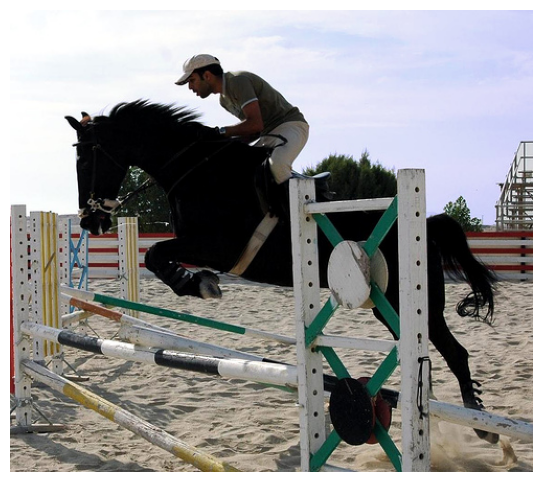

Annotation keys:
dict_keys(['folder', 'filename', 'source', 'size', 'segmented', 'object'])

Object annotation:
[{'name': 'horse', 'pose': 'Left', 'truncated': '0', 'occluded': '1', 'bndbox': {'xmin': '53', 'ymin': '87', 'xmax': '471', 'ymax': '420'}, 'difficult': '0'}, {'name': 'person', 'pose': 'Unspecified', 'truncated': '1', 'occluded': '0', 'bndbox': {'xmin': '158', 'ymin': '44', 'xmax': '289', 'ymax': '167'}, 'difficult': '0'}]


In [44]:
sample_image, sample_target = raw_train_dataset[0]

print("Image type:", type(sample_image))
print("Target type:", type(sample_target))
print("Image size:", sample_image.size)

plt.figure(figsize=(8, 6))
plt.imshow(sample_image)
plt.axis("off")
plt.show()

print("Annotation keys:")
print(sample_target["annotation"].keys())

print("\nObject annotation:")
print(sample_target["annotation"]["object"])

In [45]:
def parse_voc_annotation(target: Dict) -> Dict[str, torch.Tensor]:
    annotation = target["annotation"]
    objects = annotation.get("object", [])

    if isinstance(objects, dict):
        objects = [objects]

    boxes = []
    labels = []
    areas = []
    iscrowd = []

    for obj in objects:
        class_name = obj["name"]
        label = CLASS_TO_IDX[class_name]

        bbox = obj["bndbox"]

        xmin = float(bbox["xmin"])
        ymin = float(bbox["ymin"])
        xmax = float(bbox["xmax"])
        ymax = float(bbox["ymax"])

        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(label)

        area = (xmax - xmin) * (ymax - ymin)
        areas.append(area)

        iscrowd.append(0)

    boxes = torch.as_tensor(boxes, dtype=torch.float32)
    labels = torch.as_tensor(labels, dtype=torch.int64)
    areas = torch.as_tensor(areas, dtype=torch.float32)
    iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)

    return {
        "boxes": boxes,
        "labels": labels,
        "area": areas,
        "iscrowd": iscrowd
    }

In [46]:
class VOCDatasetForDetection(Dataset):
    def __init__(self, root: str = "./data", image_set: str = "train"):
        self.dataset = VOCDetection(
            root=root,
            year="2012",
            image_set=image_set,
            download=True
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index: int):
        image, target = self.dataset[index]

        image_tensor = F.to_tensor(image)

        detection_target = parse_voc_annotation(target)
        detection_target["image_id"] = torch.tensor([index])

        return image_tensor, detection_target

In [47]:
full_train_dataset = VOCDatasetForDetection(image_set="train")
full_val_dataset = VOCDatasetForDetection(image_set="val")

TRAIN_SUBSET_SIZE = len(full_train_dataset) // 2
VAL_SUBSET_SIZE = len(full_val_dataset) // 2

train_dataset = Subset(
    full_train_dataset,
    list(range(TRAIN_SUBSET_SIZE))
)

val_dataset = Subset(
    full_val_dataset,
    list(range(VAL_SUBSET_SIZE))
)

print(f"Full training dataset size: {len(full_train_dataset)}")
print(f"Using training dataset size: {len(train_dataset)}")

print(f"Full validation dataset size: {len(full_val_dataset)}")
print(f"Using validation dataset size: {len(val_dataset)}")

Full training dataset size: 5717
Using training dataset size: 2858
Full validation dataset size: 5823
Using validation dataset size: 2911


In [48]:
def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)


train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn
)

print("DataLoaders created.")

DataLoaders created.


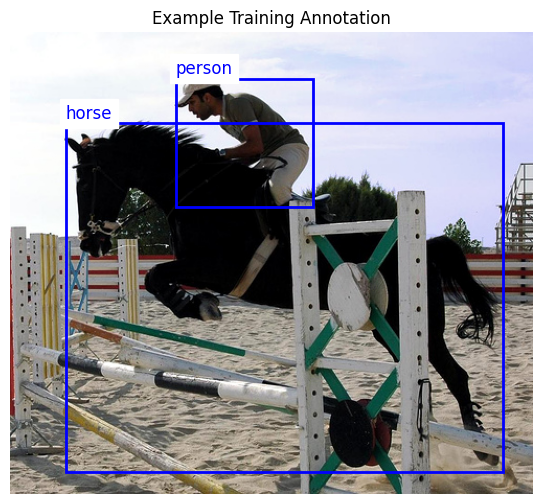

In [49]:
def draw_target_boxes(image_tensor: torch.Tensor, target: Dict, title: str = "Training Target"):
    image = image_tensor.permute(1, 2, 0).cpu().numpy()

    fig, ax = plt.subplots(1, figsize=(8, 6))
    ax.imshow(image)

    boxes = target["boxes"]
    labels = target["labels"]

    for box, label_id in zip(boxes, labels):
        xmin, ymin, xmax, ymax = box.tolist()

        width = xmax - xmin
        height = ymax - ymin

        rectangle = patches.Rectangle(
            (xmin, ymin),
            width,
            height,
            linewidth=2,
            edgecolor="blue",
            facecolor="none"
        )

        ax.add_patch(rectangle)

        label_name = IDX_TO_CLASS[int(label_id)]

        ax.text(
            xmin,
            max(ymin - 5, 0),
            label_name,
            color="blue",
            fontsize=12,
            backgroundcolor="white"
        )

    ax.set_title(title)
    ax.axis("off")
    plt.show()


example_image, example_target = train_dataset[0]

draw_target_boxes(
    image_tensor=example_image,
    target=example_target,
    title="Example Training Annotation"
)

In [50]:
def create_model(num_classes: int):
    model = fasterrcnn_resnet50_fpn(
        weights=None,
        weights_backbone=ResNet50_Weights.DEFAULT
    )

    in_features = model.roi_heads.box_predictor.cls_score.in_features

    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features,
        num_classes
    )

    return model


model = create_model(num_classes=NUM_CLASSES)
model.to(device)

print("Model created.")

Model created.


In [51]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=2,
    gamma=0.1
)

print("Optimizer and scheduler created.")

Optimizer and scheduler created.


In [52]:
def train_one_epoch(model, data_loader, optimizer, device):
    model.train()

    total_loss = 0.0

    progress_bar = tqdm(data_loader, desc="Training", leave=True)

    for images, targets in progress_bar:
        images = [image.to(device) for image in images]

        targets = [
            {key: value.to(device) for key, value in target.items()}
            for target in targets
        ]

        loss_dict = model(images, targets)

        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        batch_loss = losses.item()
        total_loss += batch_loss

        progress_bar.set_postfix(loss=batch_loss)

    average_loss = total_loss / len(data_loader)

    return average_loss

In [53]:
NUM_EPOCHS = 5

training_losses = []

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")

    average_loss = train_one_epoch(
        model=model,
        data_loader=train_loader,
        optimizer=optimizer,
        device=device
    )

    lr_scheduler.step()

    training_losses.append(average_loss)

    print(f"Average training loss: {average_loss:.4f}")


Epoch 1/5


Training:   0%|          | 0/1429 [00:00<?, ?it/s]

Average training loss: 0.5676

Epoch 2/5


Training:   0%|          | 0/1429 [00:00<?, ?it/s]

Average training loss: 0.5002

Epoch 3/5


...

Average training loss: 0.4114

Epoch 4/5


Training:   0%|          | 0/1429 [00:00<?, ?it/s]

Average training loss: 0.3819

Epoch 5/5


Training:   0%|          | 0/1429 [00:00<?, ?it/s]

Average training loss: 0.3573


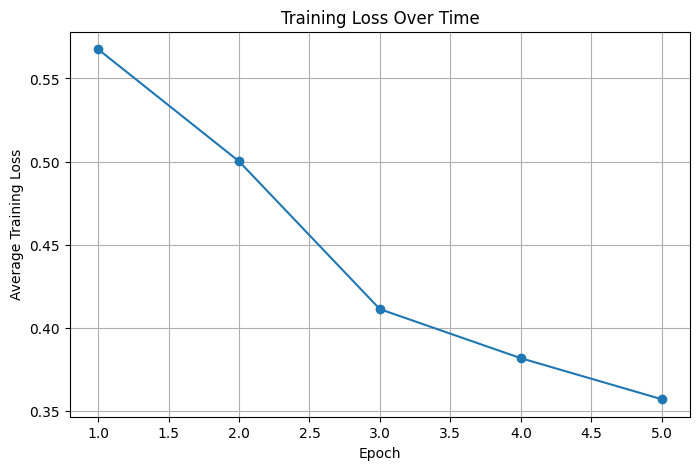

In [54]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(training_losses) + 1), training_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Training Loss Over Time")
plt.grid(True)
plt.show()

In [55]:
MODEL_PATH = "fasterrcnn_voc_small.pth"

torch.save(model.state_dict(), MODEL_PATH)

print(f"Model saved to {MODEL_PATH}")

Model saved to fasterrcnn_voc_small.pth


In [56]:
def predict_with_model(
    model,
    image_tensor: torch.Tensor,
    confidence_threshold: float = 0.5
) -> List[Dict]:
    model.eval()

    with torch.no_grad():
        prediction = model([image_tensor.to(device)])[0]

    boxes = prediction["boxes"].detach().cpu()
    labels = prediction["labels"].detach().cpu()
    scores = prediction["scores"].detach().cpu()

    cleaned_predictions = []

    for box, label_id, score in zip(boxes, labels, scores):
        score_value = float(score)

        if score_value < confidence_threshold:
            continue

        xmin, ymin, xmax, ymax = box.tolist()

        cleaned_predictions.append({
            "label": IDX_TO_CLASS[int(label_id)],
            "score": score_value,
            "bbox": (
                int(xmin),
                int(ymin),
                int(xmax),
                int(ymax)
            )
        })

    return cleaned_predictions

In [57]:
def draw_predictions(
    image_tensor: torch.Tensor,
    predictions: List[Dict],
    title: str = "Model Predictions"
):
    image = image_tensor.permute(1, 2, 0).cpu().numpy()

    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(image)

    for pred in predictions:
        label = pred["label"]
        score = pred["score"]
        xmin, ymin, xmax, ymax = pred["bbox"]

        width = xmax - xmin
        height = ymax - ymin

        rectangle = patches.Rectangle(
            (xmin, ymin),
            width,
            height,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rectangle)

        label_text = f"{label}: {score:.2f}"

        ax.text(
            xmin,
            max(ymin - 5, 0),
            label_text,
            color="red",
            fontsize=12,
            backgroundcolor="white"
        )

    ax.set_title(title)
    ax.axis("off")
    plt.show()

Number of predictions: 1
tvmonitor | 0.67 | (26, 2, 483, 288)


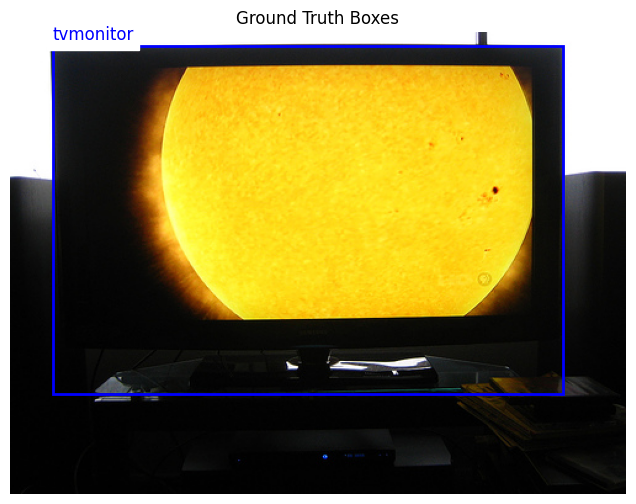

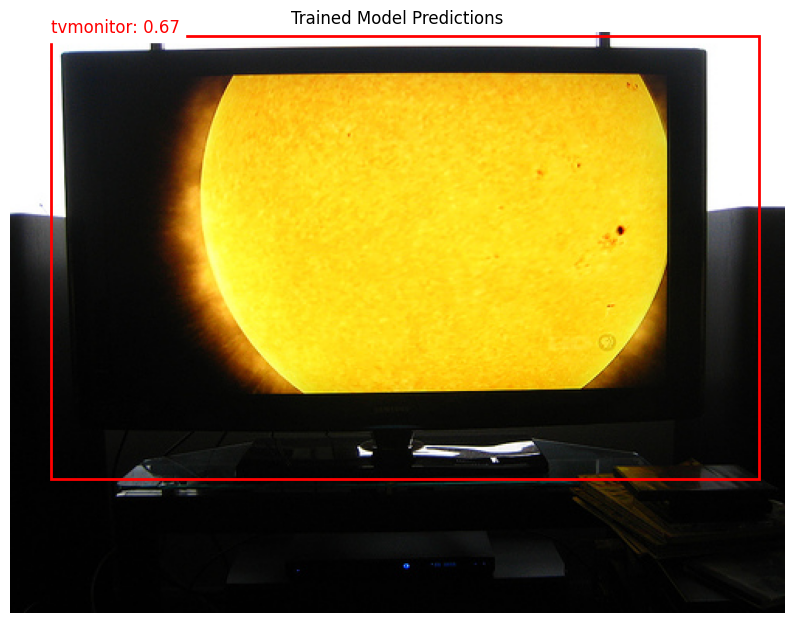

In [58]:
val_image, val_target = val_dataset[0]

val_predictions = predict_with_model(
    model=model,
    image_tensor=val_image,
    confidence_threshold=0.5
)

print(f"Number of predictions: {len(val_predictions)}")

for pred in val_predictions:
    print(f"{pred['label']} | {pred['score']:.2f} | {pred['bbox']}")

draw_target_boxes(
    image_tensor=val_image,
    target=val_target,
    title="Ground Truth Boxes"
)

draw_predictions(
    image_tensor=val_image,
    predictions=val_predictions,
    title="Trained Model Predictions"
)

Random validation index: 2170
Number of predictions: 10
chair | 0.90 | (153, 167, 225, 231)
chair | 0.79 | (232, 131, 328, 236)
chair | 0.75 | (130, 127, 175, 223)
person | 0.73 | (200, 163, 224, 227)
chair | 0.72 | (329, 145, 449, 242)
chair | 0.72 | (188, 170, 231, 230)
chair | 0.70 | (132, 146, 202, 229)
sofa | 0.61 | (0, 160, 141, 300)
sofa | 0.59 | (327, 141, 437, 262)
chair | 0.52 | (171, 169, 205, 229)


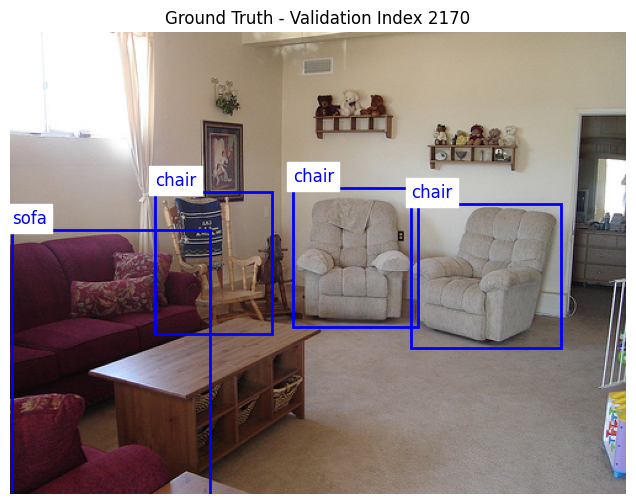

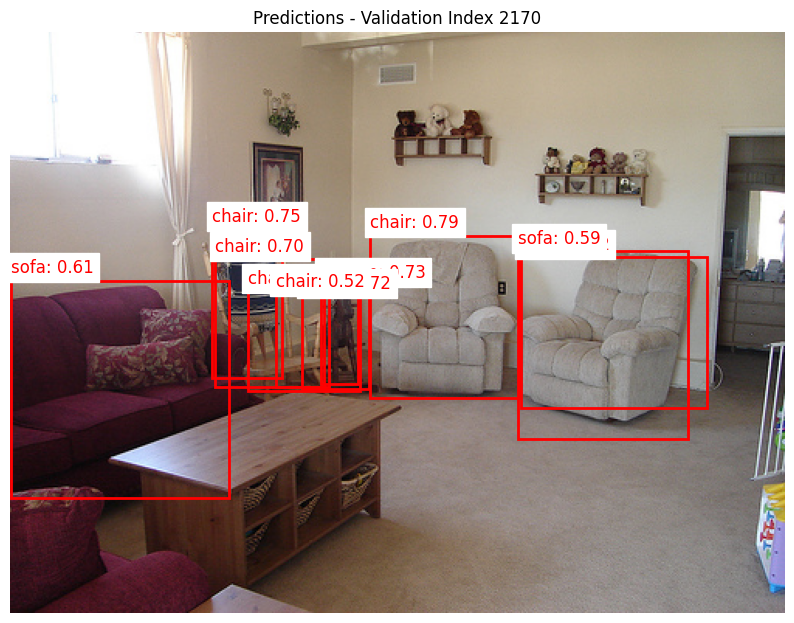

In [59]:
random_val_index = random.randint(0, len(val_dataset) - 1)

random_val_image, random_val_target = val_dataset[random_val_index]

random_val_predictions = predict_with_model(
    model=model,
    image_tensor=random_val_image,
    confidence_threshold=0.5
)

print(f"Random validation index: {random_val_index}")
print(f"Number of predictions: {len(random_val_predictions)}")

for pred in random_val_predictions:
    print(f"{pred['label']} | {pred['score']:.2f} | {pred['bbox']}")

draw_target_boxes(
    image_tensor=random_val_image,
    target=random_val_target,
    title=f"Ground Truth - Validation Index {random_val_index}"
)

draw_predictions(
    image_tensor=random_val_image,
    predictions=random_val_predictions,
    title=f"Predictions - Validation Index {random_val_index}"
)

In [60]:
thresholds = [0.2, 0.4, 0.6, 0.8]

for threshold in thresholds:
    predictions = predict_with_model(
        model=model,
        image_tensor=random_val_image,
        confidence_threshold=threshold
    )

    print(f"\nConfidence threshold: {threshold}")
    print(f"Predictions kept: {len(predictions)}")

    for pred in predictions:
        print(f"{pred['label']} | {pred['score']:.2f}")


Confidence threshold: 0.2
Predictions kept: 35
chair | 0.90
chair | 0.79
chair | 0.75
person | 0.73
chair | 0.72
chair | 0.72
chair | 0.70
sofa | 0.61
sofa | 0.59
chair | 0.52
sofa | 0.49
chair | 0.49
chair | 0.42
chair | 0.42
diningtable | 0.41
diningtable | 0.40
sofa | 0.38
sofa | 0.38
chair | 0.35
sofa | 0.33
chair | 0.32
chair | 0.29
diningtable | 0.29
sofa | 0.29
chair | 0.28
chair | 0.24
sofa | 0.24
chair | 0.24
chair | 0.23
chair | 0.22
chair | 0.22
person | 0.22
pottedplant | 0.21
chair | 0.20
person | 0.20

Confidence threshold: 0.4
Predictions kept: 15
chair | 0.90
chair | 0.79
chair | 0.75
person | 0.73
chair | 0.72
chair | 0.72
chair | 0.70
sofa | 0.61
sofa | 0.59
chair | 0.52
sofa | 0.49
chair | 0.49
chair | 0.42
chair | 0.42
diningtable | 0.41

Confidence threshold: 0.6
Predictions kept: 8
chair | 0.90
chair | 0.79
chair | 0.75
person | 0.73
chair | 0.72
chair | 0.72
chair | 0.70
sofa | 0.61

Confidence threshold: 0.8
Predictions kept: 1
chair | 0.90


In [61]:
def test_target_format(target: Dict):
    assert "boxes" in target, "Target is missing boxes."
    assert "labels" in target, "Target is missing labels."

    assert target["boxes"].ndim == 2, "Boxes should be a 2D tensor."
    assert target["boxes"].shape[1] == 4, "Each box should have 4 values."
    assert target["labels"].ndim == 1, "Labels should be a 1D tensor."

    print("Target format test passed.")


def test_prediction_format(predictions: List[Dict]):
    for pred in predictions:
        assert "label" in pred, "Prediction is missing label."
        assert "score" in pred, "Prediction is missing score."
        assert "bbox" in pred, "Prediction is missing bbox."

        assert isinstance(pred["label"], str), "Prediction label should be a string."
        assert isinstance(pred["score"], float), "Prediction score should be a float."
        assert len(pred["bbox"]) == 4, "Prediction bbox should have 4 values."

    print("Prediction format test passed.")


def test_boxes_inside_image(image_tensor: torch.Tensor, predictions: List[Dict]):
    _, height, width = image_tensor.shape

    for pred in predictions:
        xmin, ymin, xmax, ymax = pred["bbox"]

        assert xmin >= 0, "xmin is outside the image."
        assert ymin >= 0, "ymin is outside the image."
        assert xmax <= width, "xmax is outside the image."
        assert ymax <= height, "ymax is outside the image."
        assert xmax > xmin, "Box width is invalid."
        assert ymax > ymin, "Box height is invalid."

    print("Prediction box boundary test passed.")


test_target_format(val_target)
test_prediction_format(val_predictions)
test_boxes_inside_image(val_image, val_predictions)

Target format test passed.
Prediction format test passed.
Prediction box boundary test passed.


In [62]:
model.eval()

with torch.no_grad():
    raw_prediction = model([val_image.to(device)])[0]

print("Number of raw boxes:", len(raw_prediction["boxes"]))
print("Top 10 scores:", raw_prediction["scores"][:10])
print("Top 10 labels:", raw_prediction["labels"][:10])
print("Top 10 boxes:", raw_prediction["boxes"][:10])

Number of raw boxes: 16
Top 10 scores: tensor([0.6703, 0.4806, 0.4002, 0.1915, 0.1399, 0.1127, 0.0872, 0.0834, 0.0799,
        0.0793])
Top 10 labels: tensor([20, 20, 20, 20, 20,  6,  7, 20, 19, 20])
Top 10 boxes: tensor([[ 26.4154,   2.7966, 483.3439, 288.5096],
        [205.7455,   0.0000, 434.9304, 292.4816],
        [ 16.1461,   8.4251, 472.4523, 139.2129],
        [ 50.9382,   0.0000, 282.8613, 339.0627],
        [397.5634,  19.8079, 452.3149, 207.4356],
        [ 44.3039, 216.4219, 442.1493, 358.7861],
        [ 42.5854, 238.1552, 468.0906, 357.3620],
        [103.9498, 110.8806, 429.2768, 308.5717],
        [ 41.3582, 207.2193, 446.1774, 360.4183],
        [ 46.2354,   0.0000, 139.4138, 294.8255]])
